# Progetto: Filtro Fake News

Scopo: Realizzazione di un filtro per identificare le fake news, con analisi dei principali insight forniti dai dataset di partenza .

Dati di partenza: [Link al dataset](https://proai-datasets.s3.eu-west-3.amazonaws.com/fake_news.zip)


Una volta addestrato, il modello verrà esportato utilizzando pickle, così da renderlo disponibile per la messa in produzione.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import re
import os
import requests
import unicodedata
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk import word_tokenize, pos_tag, ne_chunk
from collections import Counter
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

!pip install gensim
from gensim import corpora, models
from gensim.models import CoherenceModel

from IPython.display import display, HTML

import pickle

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 16.3 MB/s eta 0:00:00


## FUNZIONI UTILIZZATE

In [ ]:
def wordcloud_maker(text):

    # Create WordCloud object with specified width, height, and background color
    wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(' '.join(text))

    # Set up the plot size
    plt.figure(figsize=(10, 5))

    # Display the word cloud image with bilinear interpolation
    plt.imshow(wordcloud, interpolation='bilinear')

    # Turn off the axis
    plt.axis('off')

    # Show the plot
    plt.show()

In [ ]:
def preprocess_text(text):

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stop words and punctuation
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word.isalnum() and word not in stop_words]

    # Remove words with 3 letters or less
    tokens = [word for word in tokens if len(word) > 3]

    # Generate bigrams and trigrams
    bigrams = ['_'.join(bigram) for bigram in ngrams(tokens, 2)]
    trigrams = ['_'.join(trigram) for trigram in ngrams(tokens, 3)]

    # Combine original tokens with bigrams and trigrams
    all_ngrams = tokens + bigrams + trigrams

    return all_ngrams

In [ ]:
def get_most_relevant_topic(lda_result):

    if lda_result:
        # Find the topic with the highest probability
        return max(lda_result, key=lambda x: x[1])[0]
    else:
        return None

## Importazione e analisi del dataset di notizie vere

In [ ]:
# Read the True News CSV file into a pandas DataFrame
df_true = pd.read_csv("/content/drive/MyDrive/True.csv")

# Display a random sample of 10 rows from the DataFrame
df_true.sample(10)

,title,text,subject,date
21162,Nearly 400 die as Myanmar army steps up crackd...,"COX S BAZAR, Bangladesh (Reuters) - Nearly 400...",worldnews,"September 1, 2017"
913,Next U.S. disaster aid approval likely in Dece...,WASHINGTON (Reuters) - The next round of aid t...,politicsNews,"November 1, 2017"
15865,Kenya chief justice says police 'enhanced' sec...,NAIROBI (Reuters) - Kenya s chief justice said...,worldnews,"November 2, 2017"
21250,U.S. send extra fighters to police Baltic skie...,SIAULIAI AIR BASE (Reuters) - The United State...,worldnews,"August 30, 2017"
20267,Amnesty International urges Egypt to release d...,CAIRO (Reuters) - Amnesty International urged ...,worldnews,"September 12, 2017"
5631,The Trump presidency on Feb. 5 at 7:10 P.M. EST,(Reuters) - Highlights of the day for U.S. Pre...,politicsNews,"February 5, 2017"
6938,Taiwan calls on China to view Trump call 'calmly',TAIPEI (Reuters) - Taiwan’s policy making body...,politicsNews,"December 3, 2016"
19509,China says North Korean situation more serious...,BEIJING (Reuters) - The situation on the Korea...,worldnews,"September 21, 2017"
10025,Democrats force postponement of committee's vo...,WASHINGTON (Reuters) - The U.S. Senate Banking...,politicsNews,"April 7, 2016"
4329,Alabama Supreme Court allows impeachment of go...,(Reuters) - The Alabama Supreme Court ruled on...,politicsNews,"April 8, 2017"


In [ ]:
# Check the shape of the DataFrame
df_true.shape

(21417, 4)

In [ ]:
# Check for missing values in the DataFrame
df_true.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [ ]:
# Count the number of empty titles in the DataFrame
df_true.title[df_true.title.str.strip() == ''].count()

np.int64(0)

In [ ]:
# Count the number of empty texts in the DataFrame
df_true.text[df_true.text.str.strip() == ''].count()

np.int64(1)

In [ ]:
# Filter rows with empty text in the DataFrame
true_text_empty_row = df_true[df_true['text'].str.strip() == '']

# Display rows with empty text
true_text_empty_row

,title,text,subject,date
8970,Graphic: Supreme Court roundup,,politicsNews,"June 16, 2016"


In [ ]:
# Remove rows with empty text
df_true.drop(8970, inplace=True)

In [ ]:
# Check for duplicated rows in the DataFrame
df_true.duplicated().sum()

np.int64(206)

In [ ]:
# Filter duplicated rows in the DataFrame
true_duplicated_rows = df_true[df_true.duplicated(keep=False)]

# Display duplicated rows
true_duplicated_rows.head(10)

,title,text,subject,date
416,Senate tax bill stalls on deficit-focused 'tri...,WASHINGTON (Reuters) - The U.S. Senate on Thur...,politicsNews,"November 30, 2017"
445,Senate tax bill stalls on deficit-focused 'tri...,WASHINGTON (Reuters) - The U.S. Senate on Thur...,politicsNews,"November 30, 2017"
762,Trump warns 'rogue regime' North Korea of grav...,BEIJING (Reuters) - U.S. President Donald Trum...,politicsNews,"November 8, 2017"
778,Trump warns 'rogue regime' North Korea of grav...,BEIJING (Reuters) - U.S. President Donald Trum...,politicsNews,"November 8, 2017"
850,"Republicans unveil tax cut bill, but the hard ...",WASHINGTON (Reuters) - U.S. House of Represent...,politicsNews,"November 2, 2017"
874,Trump taps Fed centrist Powell to lead U.S. ce...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"November 2, 2017"
892,"Republicans unveil tax cut bill, but the hard ...",WASHINGTON (Reuters) - U.S. House of Represent...,politicsNews,"November 2, 2017"
896,Trump taps Fed centrist Powell to lead U.S. ce...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"November 2, 2017"
949,"Two ex-Trump aides charged in Russia probe, th...",WASHINGTON (Reuters) - Federal investigators p...,politicsNews,"October 30, 2017"
974,"Two ex-Trump aides charged in Russia probe, th...",WASHINGTON (Reuters) - Federal investigators p...,politicsNews,"October 30, 2017"


In [ ]:
# Drop duplicates from the DataFrame based on all columns
df_true_cat = df_true.drop_duplicates()

# Display a random sample of 10 rows from the DataFrame
df_true_cat.sample(10)

,title,text,subject,date
21063,U.S. calls for U.N. to impose strongest measur...,UNITED NATIONS (Reuters) - U.S. Ambassador to ...,worldnews,"September 4, 2017"
2440,Congressman becomes first Democrat to declare ...,WASHINGTON (Reuters) - U.S. Representative Joh...,politicsNews,"July 28, 2017"
6873,California Democrats propose series of infrast...,SAN FRANCISCO (Reuters) - Democrats in Califor...,politicsNews,"December 7, 2016"
19099,Turkey turns off Kurdish Rudaw channel in wake...,ANKARA (Reuters) - Turkey took the Kurdish tel...,worldnews,"September 25, 2017"
8329,FBI to give media some Clinton notes over emai...,WASHINGTON (Reuters) - The FBI plans to hand o...,politicsNews,"August 30, 2016"
13899,Ireland trying to force Northern Ireland to st...,LONDON (Reuters) - Ireland is trying to force ...,worldnews,"November 24, 2017"
1493,"California, Wisconsin deny election systems ta...",WASHINGTON (Reuters) - California and Wisconsi...,politicsNews,"September 28, 2017"
1002,House narrowly passes measure paving way for T...,WASHINGTON (Reuters) - The U.S. House of Repre...,politicsNews,"October 26, 2017"
20835,"U.S. to send 3,500 additional troops to Afghan...",WASHINGTON (Reuters) - The United States will ...,worldnews,"September 6, 2017"
7760,Clinton accuses Trump of being Putin's 'puppet',WASHINGTON (Reuters) - Democrat Hillary Clinto...,politicsNews,"October 20, 2016"


## Importazione e analisi del dataset di notizie false

In [ ]:
# Read the Fake News CSV file into a pandas DataFrame
df_fake = pd.read_csv("/content/drive/MyDrive/Fake.csv")

# Display the first few rows of the DataFrame
df_fake.sample(10)

,title,text,subject,date
6114,Libertarian Candidate Strips On Stage During ...,"This weekend, the Libertarian Party held its a...",News,"May 29, 2016"
7225,Mitch McConnell Just Got Screwed By His Own P...,When President Obama announced his nominee to ...,News,"March 29, 2016"
21879,YOUR TAX DOLLARS PROVIDE THIS ASST PROFESSOR A...,Yep that s correct. Your hard earned tax dolla...,left-news,"Apr 10, 2015"
7035,President Obama: Hillary Clinton Is Undoubted...,Hillary Clinton was one of the most hands-on F...,News,"April 7, 2016"
17128,COLLECTING THE MONEY FOR THE WALL? MEXICO STAR...,Don t you just love the absolute boldness of t...,Government News,"Aug 20, 2015"
21315,EYE-OPENING VIDEO: Rape Epidemic In Sweden…”Th...,"In the capitol of Oslo, 100% Of assault rapes...",left-news,"Nov 19, 2015"
8045,Bette Midler’s Brilliant Tweet Perfectly Expo...,"Let s just say, hypothetically, that Donald Tr...",News,"February 17, 2016"
9996,President and First Lady Arrive in Texas: Serv...,Check out what s happening in Texas! President...,politics,"Sep 2, 2017"
21437,CASTRO IGNORES DISASTROUS COMMUNIST POLICIES T...,If Obama had a communist friend he d be this p...,left-news,"Sep 29, 2015"
19669,BREAKING! NEW Wikileaks Email: Confidential Au...,The report exposed in an email shared by Wikil...,left-news,"Nov 6, 2016"


In [ ]:
# Check for missing values in the DataFrame
df_fake.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [ ]:
# Count the number of empty titles in the DataFrame
df_fake.title[df_fake.title.str.strip() == ''].count()

np.int64(0)

In [ ]:
# Count the number of empty texts in the DataFrame
df_fake.text[df_fake.text.str.strip() == ''].count()

np.int64(630)

In [ ]:
# Filter rows with empty text in the DataFrame
fake_text_empty_row = df_fake[df_fake['text'].str.strip() == '']

# Display rows with empty text
fake_text_empty_row

,title,text,subject,date
10923,TAKE OUR POLL: Who Do You Think President Trum...,,politics,"May 10, 2017"
11041,Joe Scarborough BERATES Mika Brzezinski Over “...,,politics,"Apr 26, 2017"
11190,WATCH TUCKER CARLSON Scorch Sanctuary City May...,,politics,"Apr 6, 2017"
11225,MAYOR OF SANCTUARY CITY: Trump Trying To Make ...,,politics,"Apr 2, 2017"
11236,SHOCKER: Public School Turns Computer Lab Into...,,politics,"Apr 1, 2017"
...,...,...,...,...
21816,BALTIMORE BURNS: MARYLAND GOVERNOR BRINGS IN N...,,left-news,"Apr 27, 2015"
21826,FULL VIDEO: THE BLOCKBUSTER INVESTIGATION INTO...,,left-news,"Apr 25, 2015"
21827,(VIDEO) HILLARY CLINTON: RELIGIOUS BELIEFS MUS...,,left-news,"Apr 25, 2015"
21857,(VIDEO)ICE PROTECTING OBAMA: WON’T RELEASE NAM...,,left-news,"Apr 14, 2015"


In [ ]:
# Remove empty text rows
empty_text_rows_to_remove = fake_text_empty_row.index
df_fake = df_fake.drop(empty_text_rows_to_remove)

In [ ]:
df_fake

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [ ]:
# Check for duplicated rows in the DataFrame
df_fake.duplicated().sum()

np.int64(3)

In [ ]:
# Filter duplicated rows in the DataFrame
fake_duplicated_rows = df_fake[df_fake.duplicated(keep=False)]

# Display duplicated rows
fake_duplicated_rows

,title,text,subject,date
9941,HILLARY TWEETS MESSAGE In Defense Of DACA…OOPS...,No time to waste we've got to fight with eve...,politics,"Sep 9, 2017"
9942,HILLARY TWEETS MESSAGE In Defense Of DACA…OOPS...,No time to waste we've got to fight with eve...,politics,"Sep 9, 2017"
11445,FORMER DEMOCRAT WARNS Young Americans: “Rioter...,"Who is silencing political speech, physically...",politics,"Mar 10, 2017"
11446,FORMER DEMOCRAT WARNS Young Americans: “Rioter...,"Who is silencing political speech, physically...",politics,"Mar 10, 2017"
14924,[VIDEO] #BlackLivesMatter Terrorists Storm Dar...,They were probably just looking for a safe sp...,politics,"Nov 16, 2015"
14925,[VIDEO] #BlackLivesMatter Terrorists Storm Dar...,They were probably just looking for a safe sp...,politics,"Nov 16, 2015"


In [ ]:
# Drop duplicates from the DataFrame based on all columns
df_fake_cat = df_fake.drop_duplicates()

# Display a random sample of 10 rows from the DataFrame
df_fake_cat.sample(10)

,title,text,subject,date
3861,WATCH: Van Jones SHUTS DOWN Trump Supporter F...,Trump and his deplorable supporters worked for...,News,"November 10, 2016"
16427,THE POPE PUSHES CLIMATE JUSTICE : “Ambitious A...,"On the surface, this seems like such a simple ...",Government News,"Sep 1, 2016"
8175,WATCH: Eric Garner’s Daughter Tells The World...,Eric Garner s daughter has released a new vide...,News,"February 11, 2016"
4073,Reince Priebus Does WEIRD Balancing Act Regar...,Donald Trump s recent talk of a rigged electi...,News,"October 23, 2016"
15930,UNREAL! RIGHT BEFORE MASSACRE…#LasVegas Concer...,"Just before the gunman began shooting, the Las...",Government News,"Oct 2, 2017"
17060,FBI Warns Philly Colleges Of Threat On Monday:...,The FBI photo warning is from Drexel Universit...,Government News,"Oct 4, 2015"
11441,UNREAL! TWO FLORIDA Immigrant Politicians Inti...,"Commissioner Mack Bernard and Rep. Al Jacquet,...",politics,"Mar 10, 2017"
11246,TUCKER CARLSON EMBARRASSES Liberal Professor W...,A Drexel University professor who said he wa...,politics,"Mar 30, 2017"
23034,Trump Moves Ahead with ‘The Wall’ Between US a...,This week President Donald Trump followed thr...,Middle-east,"January 25, 2017"
2805,Ex-KGB Chief Who Leaked Incriminating Trump I...,Trump and his allies expect us to dismiss the ...,News,"January 28, 2017"


In [ ]:
df_true_cat.keys()

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [ ]:
df_fake_cat.keys()

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [ ]:
import string
import spacy
from nltk.corpus import stopwords
import re

english_stopwords = stopwords.words('english')
nlp = spacy.load('en_core_web_sm')
punctuation = set(string.punctuation)

def data_cleaner(sentence):
    sentence = sentence.lower()
    for c in string.punctuation:
        sentence = sentence.replace(c, " ")
    document = nlp(sentence)
    sentence = ' '.join(token.lemma_ for token in document)
    sentence = ' '.join(word for word in sentence.split() if word not in english_stopwords)
    sentence = re.sub('\d', '', sentence)

    return sentence

In [ ]:
# Combine 'title' and 'text' columns into a new column named 'document' with a space in between.
df_true['document'] = df_true_cat['title']+ " " + df_true_cat['text']

# Keep only the 'document' column in the DataFrame.
df_true_doc = df_true[['document']]

# Assign a new column named 'label' with value 0 to indicate that the documents in this DataFrame are true.
df_true_doc["label"] = 0

# Return the cleaned DataFrame.
df_true_doc

,document,label
0,"As U.S. budget fight looms, Republicans flip t...",0
1,U.S. military to accept transgender recruits o...,0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,0
3,FBI Russia probe helped by Australian diplomat...,0
4,Trump wants Postal Service to charge 'much mor...,0
...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,0
21413,LexisNexis withdrew two products from Chinese ...,0
21414,Minsk cultural hub becomes haven from authorit...,0
21415,Vatican upbeat on possibility of Pope Francis ...,0


### LE FAKE NEWS SONO PIU' FREQUENTI IN UNA DETERMINATA CATEGORIA?

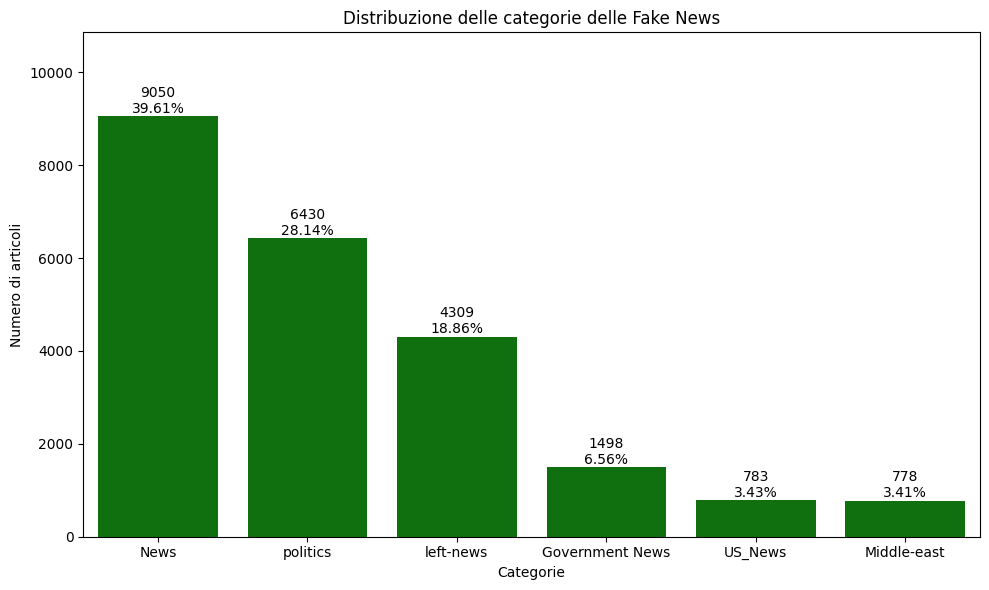

In [ ]:
# Calculate the counts of values in the DataFrame
counts = df_fake_cat['subject'].value_counts()

# Calculate the percentage relative to the total
percentages = counts / counts.sum() * 100

# Sort the counts from highest to lowest
counts_sorted = counts.sort_values(ascending=False)

# Create the countplot
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=df_fake_cat['subject'], order=counts_sorted.index, color='green')
for i, (index, count) in enumerate(counts_sorted.items()):
    plt.text(i, count + 70, f'{count}\n{percentages[index]:,.2f}%', ha='center', color='black')

# Set the range of the y-axis
plt.ylim(0, counts.max() * 1.2)

plt.title('Distribuzione delle categorie delle Fake News')
plt.xlabel('Categorie')
plt.ylabel('Numero di articoli')
plt.tight_layout()  # Adjust layout to prevent overlap of labels
plt.show()

Le FAKE NEWS sono più presenti nella categoria delle notizie generiche (NEWS).Tale evidenza potrebbe essere ricondotta a diversi fattori, quali la mancanza di verifica (fact-checking), l'ampia diffusione a favore di un pubblico tendenzialmente meno attento rispetto a chi segue uno specifico settore e l'ambiguità intrinseca nelle notizie generiche che, in quanto tali, generalmente non prevedono un approfondimento.


### PER OGNI CATEGORIA, CI SONO ARGOMENTI CHE SONO PIU' SOGGETTI ALLE FAKE NEWS?

In [ ]:
# Extract unique categories from the 'subject' column of the DataFrame
categories_fake = list(df_fake_cat['subject'].unique())
categories_fake

['News', 'politics', 'Government News', 'left-news', 'US_News', 'Middle-east']

In [ ]:
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
def topic_analyzer(category_df, category_name, num_topics=5, alpha='auto', eta='auto', iterations=100, passes=10):

    category_documents = category_df['document'].tolist()

    # Get total number of articles
    total_documents = len(category_documents)

    # Prepare text for LDA
    texts = [preprocess_text(doc) for doc in category_documents]

    # Create dictionary
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # Train LDA model
    lda_model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        alpha=alpha,
        eta=eta,
        iterations=iterations,
        passes=passes,
        random_state=42
    )

    print()

    # Extract topics
    topics = lda_model.print_topics(num_words=5)

    # Sort keywords within each topic by importance
    sorted_topics = [(topic_num, sorted(topic_str.split(" + "), key=lambda x: float(x.split("*")[0]), reverse=True)) for topic_num, topic_str in topics]

    # Add LDA result to DataFrame
    lda_results = [lda_model[dictionary.doc2bow(text)] for text in texts]

    # Sort lda_results from most important to least important
    lda_results_sorted = [sorted(result, key=lambda x: x[1], reverse=True) for result in lda_results]

    most_relevant_topics = [get_most_relevant_topic(result) for result in lda_results_sorted]

    # Add column with most relevant topic number
    category_df['lda_topic'] = lda_results_sorted
    category_df['most_relevant_topic'] = most_relevant_topics

    # Create a word cloud
    all_words = [word for doc in category_documents for word in preprocess_text(doc)]
    wordcloud_maker(all_words)

In [ ]:
df_fake_cat

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [ ]:
df_fake.keys()

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [ ]:
# Combine 'title' and 'text' columns into a new column named 'document' with a space in between.
# Ensure that both 'title' and 'text' columns are of string type before concatenation.
df_fake['subject'] = df_fake['subject'].astype(str)
df_fake['document'] = df_fake_cat['title'].astype(str) + " " + df_fake_cat['text'].astype(str)
df_fake['document'] = df_fake['document'].astype(str)

# Keep only the 'subject', 'document', and 'label' columns in the DataFrame.
df_fake_doc = df_fake[['subject', 'document']]

# Assign a new column named 'label' with value 1 to indicate that the documents in this DataFrame are fake.
df_fake_doc["label"] = 1

# Return the cleaned DataFrame.
df_fake_doc.sample(10)

,subject,document,label
8282,News,Trump Tried To Give $100K Bribe To Vets To Be...,1
15916,Government News,LAWYER FOR FBI INFORMANT Knows of Russian Brib...,1
20008,left-news,FLASHBACK [VIDEO]: Libertarian Gary Johnson Di...,1
1390,News,WATCH: Students WALK OUT During Mike Pence’s ...,1
22761,Middle-east,The Las Vegas Mass Shooting – More to the Stor...,1
21535,left-news,DISABLED MAN WITH CANE CONFRONTS 3 PUNKS STAND...,1
5886,News,Microsoft Just Gamed Our Tax System With Its ...,1
10724,politics,EVERY BAD THING We Can Say Goodbye To With Our...,1
4141,News,Ivanka Trump FINALLY Has Something To Say Abo...,1
13642,politics,BREAKING: IT’S “INDEPENDENCE DAY!”…HISTORIC UK...,1


#### ANALISI CATEGORIA "NEWS"

In [ ]:
df_fake_cat

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


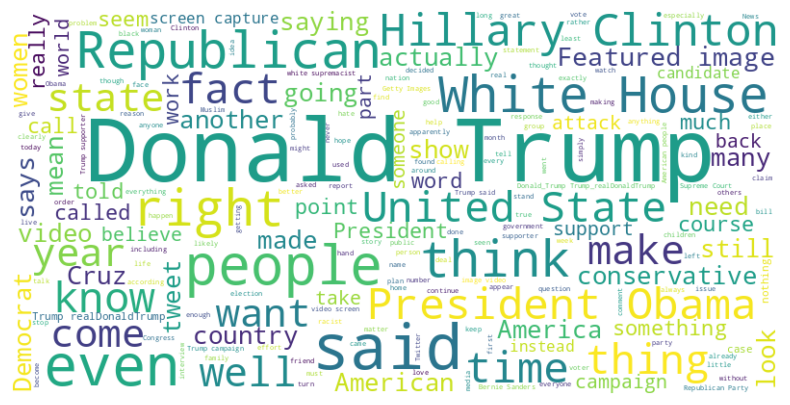

In [ ]:
# Define the current category name
current_category_name = "News"


# Define LDA params
params = {
    'num_topics': 2,
    'alpha': 0.3,
    'eta': 0.4,
    'iterations': 750,
    'passes': 15
}

# Filter the DataFrame to only include rows where the 'subject' column matches the current category name
current_category_df = df_fake_doc[df_fake_doc['subject'] == current_category_name]

# Pass the filtered DataFrame and the current category name to a function to analyze topic
topic_analyzer(current_category_df, current_category_name, **params)

I termini che si distinguono nella sottocategoria "News" fanno riferimento alla politica americana, ed in particolare ai presidenti Trump e Obama e alla senatrice Clinton. Vi è un significativo utilizzo dei termini "white house", "republican" e "people", ma anche il richiamo al verbo "to say". Dall'analisi di utilizzo dei predetti termini emerge che la politica interna degli Stati Uniti è senza dubbio l'argomento principale anche delle notizie generiche; in particolare, l'associazione tra i nomi dei leaders politici USA e i richiami alla nazione e al popolo americano inducono a ritenere che i principali argomenti trattati possano riguardare il rapporto tra il popolo americano ed il suo presidenze e, quindi, le ricadute sulla popolazione delle dichiarzioni rese e dei provevdimenti adotatti dal Capo della Casa Bianca.

#### ANALISI CATEGORIA "POLITICS"

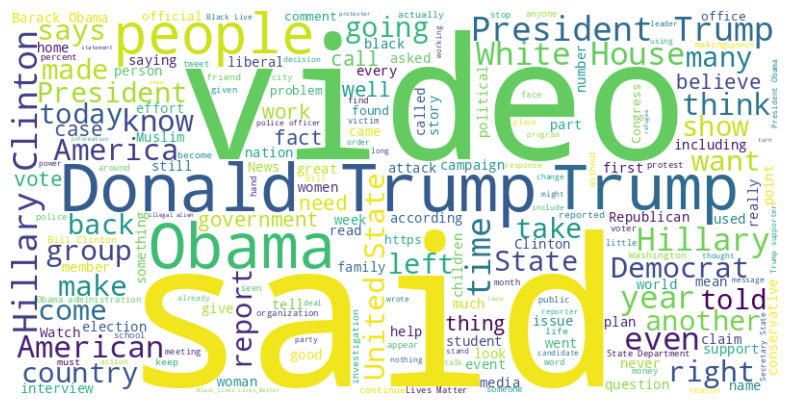

In [ ]:
# Define the current category name
current_category_name = 'politics'

# Define LDA params
params = {
    'num_topics': 3,
    'alpha': 0.2,
    'eta': 0.1,
    'iterations': 1000,
    'passes': 10
}

# Filter the DataFrame to only include rows where the 'subject' column matches the current category name
current_category_df = df_fake_doc[df_fake_doc['subject'] == current_category_name]

# Pass the filtered DataFrame and the current category name to a function to analyze topic
topic_analyzer(current_category_df, current_category_name, **params)

Nella sottocategoria 'politics', gli argomenti predominanti riguardano le figure di spicco della politica USA, come i presidenti americani Obama e Trump e la senatrice Hillary Clinton.  Particolarmente rilevante è l'altissima presenza del termine "video" e del verbo "to say": ciò induce a ritenere che i principali argomenti riguardino filmati e/o dichiarazioni attribuibili ai leadres politici precedentemente citati.

#### ANALISI CATEGORIA "GOVERMENT NEWS"

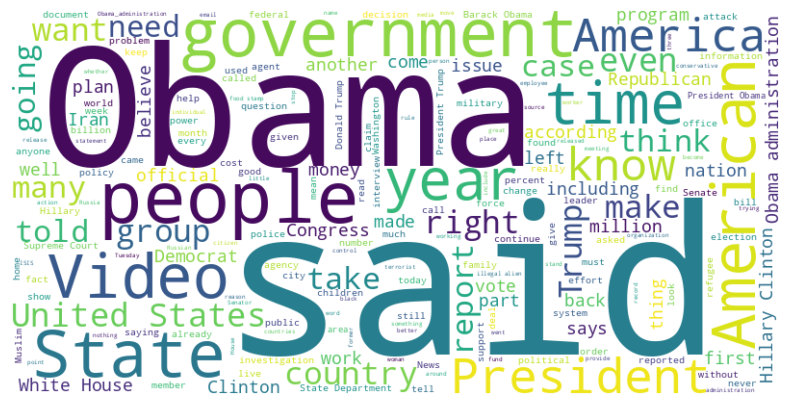

In [ ]:
# Define the current category name
current_category_name = 'Government News'

# Define LDA params
params = {
    'num_topics': 4,
    'alpha': 0.1,
    'eta': 0.1,
    'iterations': 1000,
    'passes': 10
}

# Filter the DataFrame to only include rows where the 'subject' column matches the current category name
current_category_df = df_fake_doc[df_fake_doc['subject'] == current_category_name]

# Pass the filtered DataFrame and the current category name to a function to analyze topic
topic_analyzer(current_category_df, current_category_name, **params)

Nella sottocategoria "Government News" i termini principalmente ruotano attorno alla figura del presidente USA (Obama soprattutto, ma anche Trump) e alle azioni di governo proposte e/o adottate. Significativo appare il riferimento al popolo, mentre su tutti spicca il verbo "to say" (nella versione passata "said"): ciò induce a ritenere che gli argomenti con maggior frequenza possano riguardare dichiarazioni rilasciate dal presidente degli Stati Uniti nei confronti del popolo americano.

#### ANALISI CATEGORIA "LEFT-NEWS"

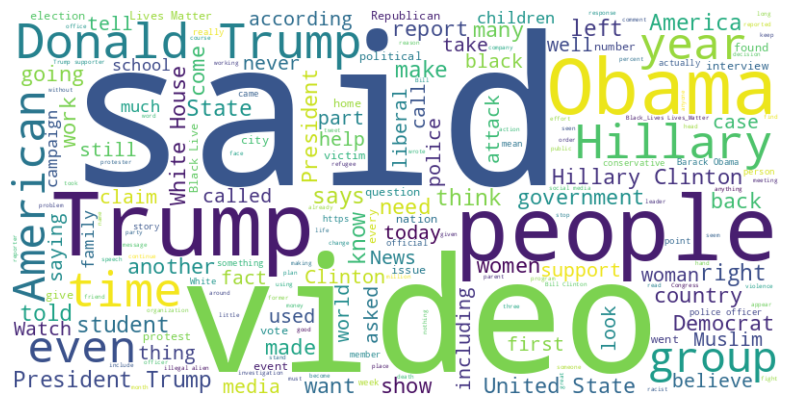

In [ ]:
# Define the current category name
current_category_name = 'left-news'

# Define LDA params
params = {
    'num_topics': 2,
    'alpha': 0.2,
    'eta': 0.6,
    'iterations': 1000,
    'passes': 20
}

# Filter the DataFrame to only include rows where the 'subject' column matches the current category name
current_category_df = df_fake_doc[df_fake_doc['subject'] == current_category_name]

# Pass the filtered DataFrame and the current category name to a function to analyze topic
topic_analyzer(current_category_df, current_category_name, **params)

Nella sottocategoria "left-news" spicca l'intenso utilizzo dei termini "Trump", "Obama" e "Hillary" attribuibili ai principali attori politici americani; tuttavia, su tutti, spicca il verbo "to say", ma anche i termini "video" e "people": ciò fa ritenere plausibile che i principali argomenti potrebbero riguardare dichiarazioni, azioni o opinioni associate a queste figure politiche.







#### ANALISI CATEGORIA "US_NEWS"

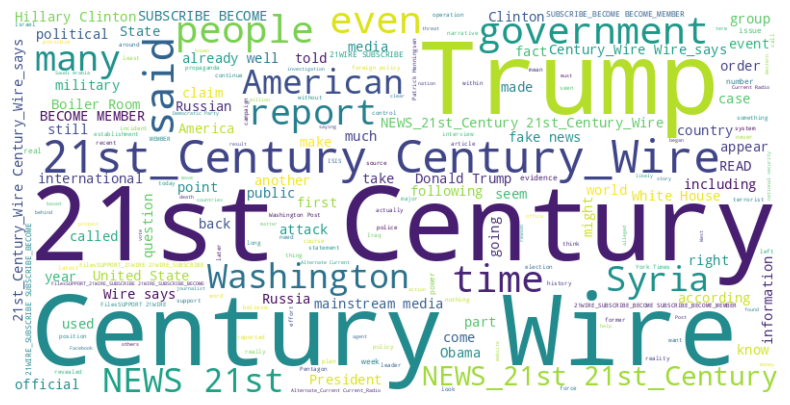

In [ ]:
# Define the current category name
current_category_name = 'US_News'

# Define LDA params
params = {
    'num_topics': 4,
    'alpha': 0.2,
    'eta': 0.6,
    'iterations': 300,
    'passes': 15
}

# Filter the DataFrame to only include rows where the 'subject' column matches the current category name
current_category_df = df_fake_doc[df_fake_doc['subject'] == current_category_name]

# Pass the filtered DataFrame and the current category name to a function to analyze topic
topic_analyzer(current_category_df, current_category_name, **params)

I termini principalmente utilizzati nella sottocategoria "US-News" sono "21st century" e "Trump".  Il termine "21st century" suggerisce un sistematico riferimento ad un contesto storico-temporale proiettato sulle azioni presenti e future.

#### ANALISI CATEGORIA "MIDDLE-EAST"

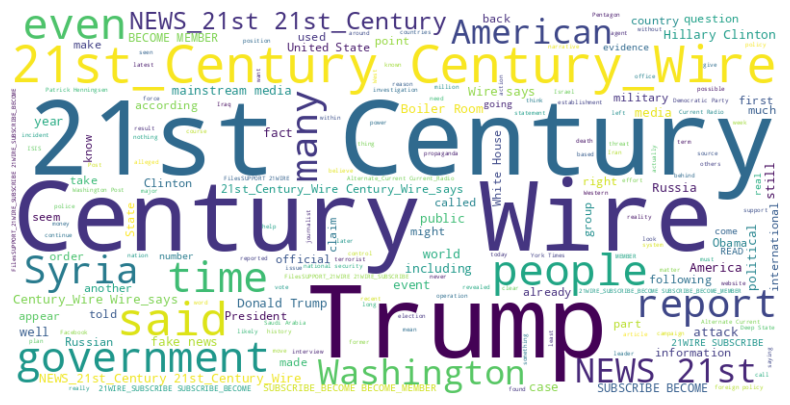

In [ ]:
# Define the current category name
current_category_name = 'Middle-east'

# Define LDA params
params = {
   'num_topics': 4,
   'alpha': 0.2,
   'eta': 0.6,
   'iterations': 300,
   'passes': 15
}

# Filter the DataFrame to only include rows where the 'subject' column matches the current category name
current_category_df = df_fake_doc[df_fake_doc['subject'] == current_category_name]

# Pass the filtered DataFrame and the current category name to a function to analyze topic
topic_analyzer(current_category_df, current_category_name, **params)

Nella categoria "Middle-East" i termini più ricorrenti risultano essere "Trump", "21st century", "time", ma anche il verbo "to say" e "wire" unitamente a "Syria" 2 "Russia". L'utilizzo frequente di queste parole e/o verbi suggerisce che gli argomenti possano riguardare dichiarazini attribuibili al presidente Trump con riferimento al periodo storico e alle principali questioni di politica estera, con particolare riferimento al Medio-Oriente e ai rapporti con la Russia.

## I TITOLI DELLE FAKE NEWS PRESENTANO DEI PATTERN?

Per determinare se i titoli delle fake news presentano dei pattern, si possono analizzare le parti del discorso (POS) in modo da identificare i ruoli grammaticali di ciascuna parola (come nomi, verbi, aggettivi), nei titoli delle fake news.

In [ ]:
# Extracting titles of fake news
fake_titles = df_fake_cat['title']

# Tokenization and POS tagging
pos_tags = []
for title in fake_titles:
    words = preprocess_text(title)  # Tokenize the title into words
    pos_tags.extend(pos_tag(words))  # Perform POS tagging on the tokenized words

# Counting the most common parts of speech
pos_counts = Counter(tag for word, tag in pos_tags)  # Count occurrences of each POS tag
pos_counts_sorted = dict(sorted(pos_counts.items(), key=lambda item: item[1], reverse=True))
pos_counts_sorted_filtered = {key: val for key, val in pos_counts_sorted.items() if val > 2000}

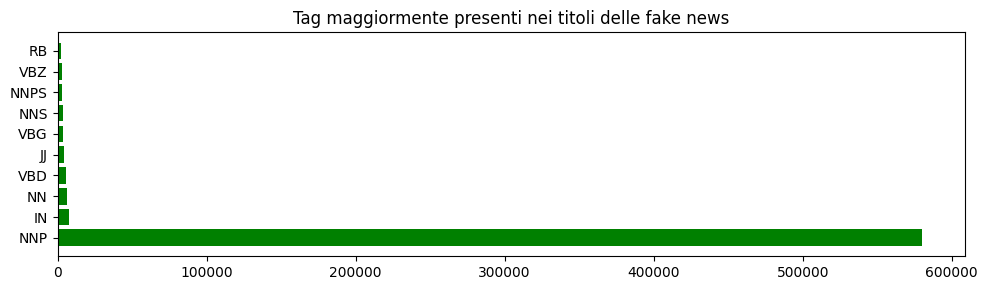

In [ ]:
# Create a barh to show tag's count
plt.figure(figsize=(10, 3))
labels = list(pos_counts_sorted_filtered.keys())
values = list(pos_counts_sorted_filtered.values())
plt.barh(labels, values, color='green')
plt.title("Tag maggiormente presenti nei titoli delle fake news")
plt.tight_layout()
plt.show()

Dai questi risultati posso notare che il tag in assoluto più frequente è, di gran lunga:

- NNP (nomi propri singolari)

Altri tag presenti, ma decisamente meno frequeni, sono:

- JJ (aggettivi)
- NN (sostantivi singolari o plurali)
- NNS (sostantivi plurali)
- VBG (verbi gerundi o participio presente)
- VBD (verbi passati)
- VBZ (verbi terza persona singolare presente)
- VBP (verbi presenti tranne la terza persona singolare)
- RB (avverbi)

L'analisi eseguita sul tipo di termini utilizzati permette di evidenziare che i nomi propri (NNP) risultano di gran lunga i più utilizzati: questo porta a desumere che, di massima, gli articoli contengano riferimenti diretti ad azioni compiute e/o dichiarazioni rese da persone.

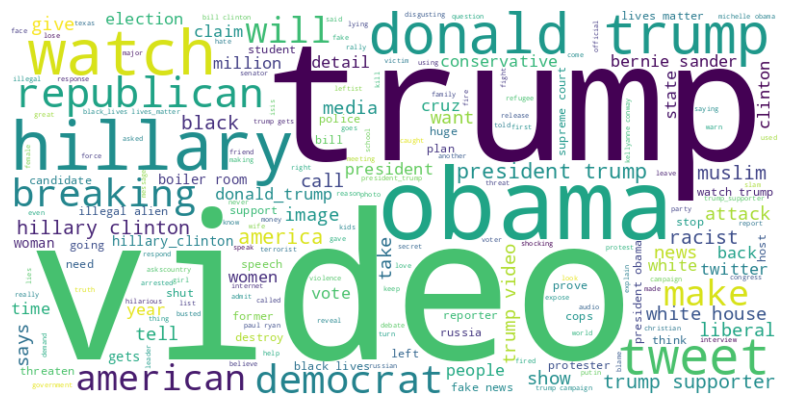

In [ ]:
# Extracting words from fake news titles
words_fake = [word.lower() for title in fake_titles for word in preprocess_text(title)]

# Creating the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words_fake))

# Visualizing the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Le parole più ricorrenti nei titoli delle fake news sono "Trump", "video", "Obama", "Hillary (Clinton), "watch", "republican" e "democrat". Con ragionevole margine di sicurezza è possibile affermare che i titoli delle fake news riguardino principalmente la politica americana ed i suoi principali esponenti. Lo strumento mediatico più invocato è senza dubbio il video: un richiamo ad un filmato nel quale un personaggio politico di primo piano esterna delle dichiarazioni sembra essere il pattern ricorrente delle fake news.

## CREAZIONE DEL MODELLO PER IDENTIFICARE LE FAKE NEWS

In [ ]:
# Combine 'title' and 'text' columns into a new column named 'document' with a space in between.
df_fake['document'] = df_fake_cat['title'] + " " + df_fake_cat['text']

# Keep only the 'document' column in the DataFrame.
df_fake_doc = df_fake[['document']]

# Assign a new column named 'label' with value 1 to indicate that the documents in this DataFrame are fake.
df_fake_doc["label"] = 1

# Return the cleaned DataFrame.
df_fake_doc

,document,label
0,Donald Trump Sends Out Embarrassing New Year’...,1
1,Drunk Bragging Trump Staffer Started Russian ...,1
2,Sheriff David Clarke Becomes An Internet Joke...,1
3,Trump Is So Obsessed He Even Has Obama’s Name...,1
4,Pope Francis Just Called Out Donald Trump Dur...,1
...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,1
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,1
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,1
23479,How to Blow $700 Million: Al Jazeera America F...,1


In [ ]:
df_true_doc['document'] = [data_cleaner(document) for document in df_true_doc['document'].astype(str)]

In [ ]:
df_true_doc

,document,label
0,u budget fight loom republicans flip fiscal sc...,0
1,u military accept transgender recruit monday p...,0
2,senior u republican senator let mr mueller job...,0
3,fbi russia probe help australian diplomat tip ...,0
4,trump want postal service charge much amazon s...,0
...,...,...
21412,fully commit nato back new u approach afghanis...,0
21413,lexisnexis withdraw two product chinese market...,0
21414,minsk cultural hub become authority minsk reut...,0
21415,vatican upbeat possibility pope francis visit ...,0


In [ ]:
df_fake_doc['document'] = [data_cleaner(document) for document in df_fake_doc['document'].astype(str)]

In [ ]:
df_fake_doc

,document,label
0,donald trump send embarrassing new year ’s eve...,1
1,drunk bragging trump staffer start russian col...,1
2,sheriff david clarke become internet joke thre...,1
3,trump obsessed even obama ’s name code website...,1
4,pope francis call donald trump christmas speec...,1
...,...,...
23476,mcpain john mccain furious iran treat sailor w...,1
23477,justice yahoo settle e mail privacy class acti...,1
23478,sunnistan ally ' safe zone ' plan take territo...,1
23479,blow million al jazeera america finally call ...,1


In [ ]:
# Concatenate true and fake news DataFrames into one DataFrame.
df_full = pd.concat([df_true_doc, df_fake_doc])

# Sample 10 rows from the merged DataFrame to display.
df_full.sample(10)

,document,label
11749,nan,0
524,senate vote tax plan week republican say wash...,0
19179,france le pen congratulate german far right af...,0
6349,new north dakota governor expect controversial...,0
17346,young man sponsor cair invite white house hard...,1
22792,jimmy carter ' korean want peace treaty replac...,1
9233,trump disappoint republican criticism judge co...,0
6716,ex cia chief say trump risk blame attack skip ...,0
23073,boiler room – swear jar overfloweth tune alte...,1
374,trump claim isis obama scorecard say lie terro...,1


In [ ]:
# Initialize a TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Convert the 'document' column of the DataFrame to a TF-IDF matrix representation
X = tfidf_vectorizer.fit_transform(df_full['document'])

# Define the target variable
y = df_full['label']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training using Support Vector Machine (SVM) classifier
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

## VALUTAZIONE DEL MODELLO

In [ ]:
# Predict labels for the test data using the trained SVM model
y_pred = svm_model.predict(X_test)
# Print classification report to evaluate the model's performance
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4306
           1       1.00      0.99      0.99      4548

    accuracy                           0.99      8854
   macro avg       0.99      0.99      0.99      8854
weighted avg       0.99      0.99      0.99      8854



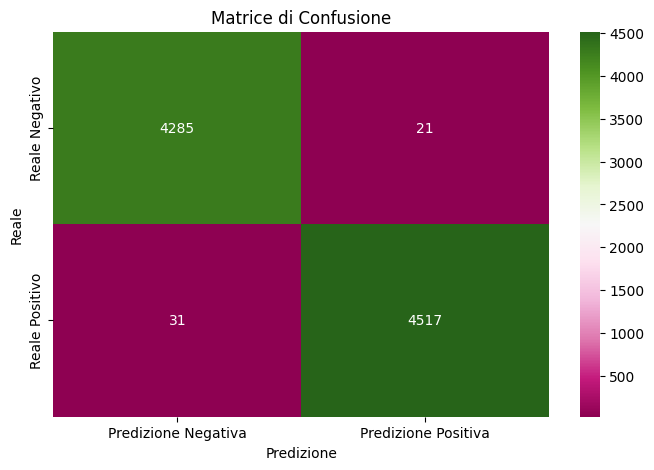

In [ ]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="PiYG", xticklabels=['Predizione Negativa', 'Predizione Positiva'], yticklabels=['Reale Negativo', 'Reale Positivo'])
plt.xlabel('Predizione')
plt.ylabel('Reale')
plt.title('Matrice di Confusione')
plt.show()

## Interpretazione delle Metriche

TP = True Positive - FP = False Positive - TN = True Negative - FN = False Positive

**Precision (Precisione)**: La precisione rappresenta la proporzione di veri positivi (TP) rispetto al totale delle predizioni positive (TP + FP). Questa metrica restituisce la capacità del modello di non classificare come positivi esempi che in realtà sono negativi.

**Recall (Richiamo)**: Il richiamo indica la proporzione di veri positivi (TP) rispetto al totale dei veri esempi positivi (TP + FN). Questa metrica misura la capacità del modello di trovare tutti gli esempi positivi.  

**F1-score**: L'F1-score calcola la media armonica di precisione e richiamo. Si tratta di un buon indicatore della performance complessiva del modello.

**Supporto (Support)**: Il supporto restituisce il numero di esempi presenti in ciascuna classe del dataset di test.

**Accuracy (Accuratezza)**: L'accuratezza è la proporzione di predizioni corrette (TP + TN) rispetto al totale delle predizioni (TP + TN + FP + FN).

**Macro Average (Media Macro)**: La media macro è la media semplice delle metriche (precision, recall, F1-score) calcolata per ciascuna classe, senza considerare il numero di esempi per classe.

**Weighted Average (Media Ponderata)**: La media ponderata tiene conto della proporzione di esempi in ciascuna classe quando calcola la media delle metriche.
   

###**Risultati**
**Precision**:
  - Classe 0: 0.99
  - Classe 1: 1.00

**Recall**:
  - Classe 0: 1.00      
  - Classe 1: 0.99

**F1-score**:
  - Classe 0: 0.99
  - Classe 1: 0.99

**Support**:
  - Classe 0: 4285
  - Classe 1: 4517

**Accuracy**:
  - 0.99 su 8854 esempi
  
**Macro Average**:
  - 0.99

**Weighted Average**:
  - 0.99


## Valutazione Complessiva del Modello

Le metriche ottenute evidenziano una complessiva bontà del modello di classificazione utilizzato nel distinguere le notizie vere da quelle false, rispetto al dataset di partenza.


## Esportazione del Modello in un file formato pkl

In [ ]:
# Save model to a pickle file
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

Riferimenti:
- https://stackoverflow.com
- https://kaggle.com
- https://github.com
- https://aicompetence.org/topic-modeling-with-nltk-and-lda/
- https://www.machinelearningplus.com/nlp/topic-modeling-gensim-python/
- https://machinelearningmastery.com/gentle-introduction-bag-words-model/
